# Assignment 3: The Experiment
## Task: Random Failure Degradation within different Network Architectures

### Task Summary
This experiment covers the investigation of Random Failure Degradation (RFD) across various network architectures. This will look at a number of different architectures of complex networks such as Erdős–Rényi (ER), Power-Law (PL), and multiple forms of Grid networks. The objective is to identify the behavioural differences (if any) between these typologies under RFD. The experiment is specifically interested in finding information to the following questions:

1. Which network architectures fare the best under random failure degradation?
2. What responses do we see from networks under random failure degradation? Specifically looking at the following changes in metrics to:
    - Shortest Path
    - Degree Distribution
    - Clustering Coefficient
    - The state of the giant component (size and connectivity)
    - Network Connectivity
3. At what point in each typology do we see the collapse in network connectivity?


### Experiment Design

The experiment will be focused on the following core typologies of networks: Erdős–Rényi, Power-Law, and 2D, 3D, and 4D Grid Networks. It will explore the key behavioural differences between these typologies when subjected to random failure degradation across incremental stages of degradation at a constant rate. The work carried out in this experiment is as follows:

1. Generate the different typologies of networks. Grid networks (N ≈ 10⁵) are the primary subject of the brief and are built once per experiment as their topology is deterministic. ER and PL networks (N = 20,000) serve as well-understood comparison baselines and generate a fresh network for each simulation run to capture variance across different realisations.
2. Subject the networks to random failure degradation across incremental stages of a constant failure probability. The simulation tracks two notions of failure: first disconnection (graph is no longer fully connected) and the operational collapse criterion used for stopping and comparisons in this notebook.
3. Evaluate the changes in the metrics listed above across the stages of degradation, through visualisations of the behaviour across multiple simulation runs and typologies.
4. An analysis of the behaviour of the different typologies under RFD to answer the questions outlined in the task summary.

#### Early Stopping 
This experiment employs early stopping to avoid unnecessary processing when the interested metrics have already been captured. This is to prevent lengthy simulation times and to reduce the processing load. Early stopping is measured by the collapse of the giant component as defined in a later section.

#### Evaluation Metrics
The following metrics are recorded at every failure stage:
1. Shortest Path
2. Degree Distribution
3. Clustering Coefficient
4. The state of the giant component (size and diameter)
5. Network Connectivity (diameter and full-connectivity flag)

#### Typology Sections
The experiment is divided into stages related to the typology of the network. Each stage runs the same random failure degradation process and evaluates the same metrics, allowing comparison across typologies. At the end of each stage, commentary on that typology's performance under degradation is provided.

#### Network Architectures
In this experiment, the focus is limited to the following network architectures:

1. Erdős–Rényi Networks
<figure>
<img src="Notebook%20Resources/ER%20Network.png" style="width:50%; height:50%; display: block; margin-left: auto; margin-right: auto;">
<figcaption align = "center"> Image: Erdős–Rényi Network example</figcaption>
<figcaption align = "center"> Source: https://mmids-textbook.github.io/_images/a5a1fbd0498f23ac9641301349d2049a81e0c0429cbc15d654f9a3d72005ae43.png</figcaption>
</figure>

ER networks (shown above) are randomly generated each time they are created, meaning their structure changes between runs even when parameters are held constant. Degree distribution follows a Poisson distribution centred on the mean degree. Clustering in these networks tends to be low, as connections are determined by an independent Bernoulli process with no mechanism to form triangles preferentially.
2. Power-Law Networks
<figure>
<img src="Notebook%20Resources/Powerlaw.png" style="width:50%; height:50%; display: block; margin-left: auto; margin-right: auto;">
<figcaption align = "center"> Image: Power-Law Network example</figcaption>
<figcaption align = "center"> Source: https://www.researchgate.net/figure/An-illustration-of-a-search-on-a-power-law-graph-Starting-at-a-node-having-a-single_fig5_1834183</figcaption>
</figure>

Power-Law networks create connections via a preferential-attachment mechanism. A small number of nodes accumulate a very high degree whilst the majority remain low-degree. These high-degree "hub" nodes are integral to maintaining connectivity across the overall network.

3. Grid Networks (2D, 3D, and 4D)

These are deterministic networks which, given a fixed node count and dimension count, produce the same structure every time. Each node connects only to its immediate neighbours along each axis, giving interior nodes exactly *2d* edges.
<figure>
<img src="Notebook%20Resources/2D%20Network.png" style="width:50%; height:50%; display: block; margin-left: auto; margin-right: auto;">
<figcaption align = "center"> Image: 2D Grid Network example</figcaption>
<figcaption align = "center"> Source: https://www.researchgate.net/figure/D-mesh-of-width-4-with-no-wraparound-connections-on-edge-or-corner-nodes_fig1_258653871</figcaption>
</figure>

For 2D networks (above), each interior node connects to its four nearest neighbours in a regular lattice.
<figure>
<img src="Notebook%20Resources/3D%20Grid%20Network.webp" style="width:50%; height:50%; display: block; margin-left: auto; margin-right: auto;">
<figcaption align = "center"> Image: 3D Grid Network example</figcaption>
<figcaption align = "center"> Source: https://www.researchgate.net/figure/A-graph-of-a-cube-with-27-nodes-and-54-edges-Note-that-only-nodes-within-a-distance-of_fig1_362066210</figcaption>
</figure>

<figure>
<img src="Notebook%20Resources/4D%20Grid%20Network.png" style="width:40%; height:40%; display: block; margin-left: auto; margin-right: auto;">
<figcaption align = "center"> Image: 4D Grid Network example</figcaption>
<figcaption align = "center"> Source: https://www.researchgate.net/figure/A-Four-dimensional-hypercube-System-52-Hypercubic-P2P-Grid-Topology-The-Hypercubic-P2P_fig13_46093648</figcaption>
</figure>

For 3D and 4D networks (above), the same lattice structure extends into additional dimensions, increasing the number of neighbours per interior node to 6 and 8 respectively. Given the uniform structure of these networks, degree distribution and clustering coefficient, we imagine, to remain consistent throughout each dimension. It is expected that higher node values will replicate the same behaviour given that the nature of their structure is not random. 


### Existing Literature
Previous studies indicate that the selected network topologies respond differently to RFD:

- **Grid Networks**: Grid resilience under RFD is strongly dependent on dimensionality. Higher-dimensional grids benefit from more redundant pathways, which the literature suggests improves resilience (Cuadra et al., 2015; Mureddu et al., 2016). However, lower-dimensional lattices such as a 2D grid have a maximum of four neighbours per interior node, providing little path redundancy; removing edges at random is therefore expected to cause a relatively rapid decline in connectivity.
- **ER Networks**: These show strong resistance to RFD due to the decentralised nature of the architecture — the stochastic, uniform connection process avoids the creation of critical hub nodes. The literature suggests a slow decline in overall connectivity and giant component size.
- **PL Networks**: These are expected to be more vulnerable to RFD than ER networks. While early stages show resilience — most edges connect low-degree peripheral nodes — the eventual random severing of hub connections can accelerate connectivity decline significantly. Susceptibility relative to grid networks will depend on the dimensionality of the grid being compared.

#### Random Failure Degradation
Random Failure Degradation (RFD) is the process of stochastically removing edges from the network. At each stage, every remaining edge is independently removed with probability `FAILURE_RATE`. This means at every stage a random percentage of the remaining nodes are removed from the network. This failure rate will be consistent at each stage and each typology tested in the experiment. 


#### Collapse Definition
In this notebook, collapse is defined as giant-component failure: the run stops when the largest connected component falls below 50% of nodes. First disconnection (graph not fully connected) is still tracked in the metrics and discussed separately where relevant.

# Prior setup code for the experiment
Before proceeding with the experiments, run the following code to ensure that all needed packages and dependencies are present on the machine before running the experiment.

For reproducibility, the visualisations use the in-memory results generated by each simulation cell. Each completed experiment also writes its current results and parameters to the corresponding JSON file in `simulation_exports/`.

In [1]:
#Checks that python 3.8 or higher is being used
import sys
assert sys.version_info >= (3, 8), "This notebook requires Python 3.8 or higher."

In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from functools import partial

import NetworkGenerator as ng
import RandomFailure as rf
import SimulationRunner as sr
import Visualisation as vis
import Metrics as mt

from SimulationRunner import SimulationRunner
from Visualisation import SimulationVisualiser


If this has completed successfully, then we can proceed with the experiment. If not, consult the error messages and ensure that your system is set up for running the experiment. 

In [4]:
# ── Experiment-wide parameters ──────────────────────────────────────────────
NUM_RUNS         = 10
FAILURE_RATE     = 0.1
RUNS_IN_PARALLEL = True   # Independent simulations run in separate processes.
MAX_WORKERS      = 10      # Conservative for large graphs; increase only if memory allows.

runner = SimulationRunner()


# Important Note
Some of the simulations that are run are large and complex and as such may take some time to run through the entire process. 


# Experiment 1: Erdős–Rényi Networks


### Simulation Setup and Run
This section runs repeated experiments on the ER network. The solution provides options to adjust the number of nodes and edge-creation probability. Increasing density or run count can significantly increase processing time.

Each simulation run now generates a fresh ER network and runs the failure process once on that network.

In [5]:
ER_NODE_COUNT = 100000
ER_EDGE_PROBABILITY = 0.00004

er_graph_factory = partial(
    ng.generate_er_network,
    node_count=ER_NODE_COUNT,
    edge_probability=ER_EDGE_PROBABILITY,
)
er_runs = runner.run_experiment(
    graph_factory=er_graph_factory,
    num_runs=NUM_RUNS,
    failure_rate=FAILURE_RATE,
    run_parallel=RUNS_IN_PARALLEL,
    max_workers=MAX_WORKERS,
)

runner.export_results(
    er_runs,
    "simulation_exports/erdos-renyi_runs.json",
    "Erdos-Renyi",
    {
        "node_count": ER_NODE_COUNT,
        "edge_probability": ER_EDGE_PROBABILITY,
        "failure_rate": FAILURE_RATE,
        "num_runs": NUM_RUNS,
    },
)

print(f"Erdos-Renyi: completed {len(er_runs)} simulation runs (new network per run).")


Erdos-Renyi: completed 10 simulation runs (new network per run).


### Simulation Visualisation
Now that the simulation has been run, the results can be displayed using the below code. 

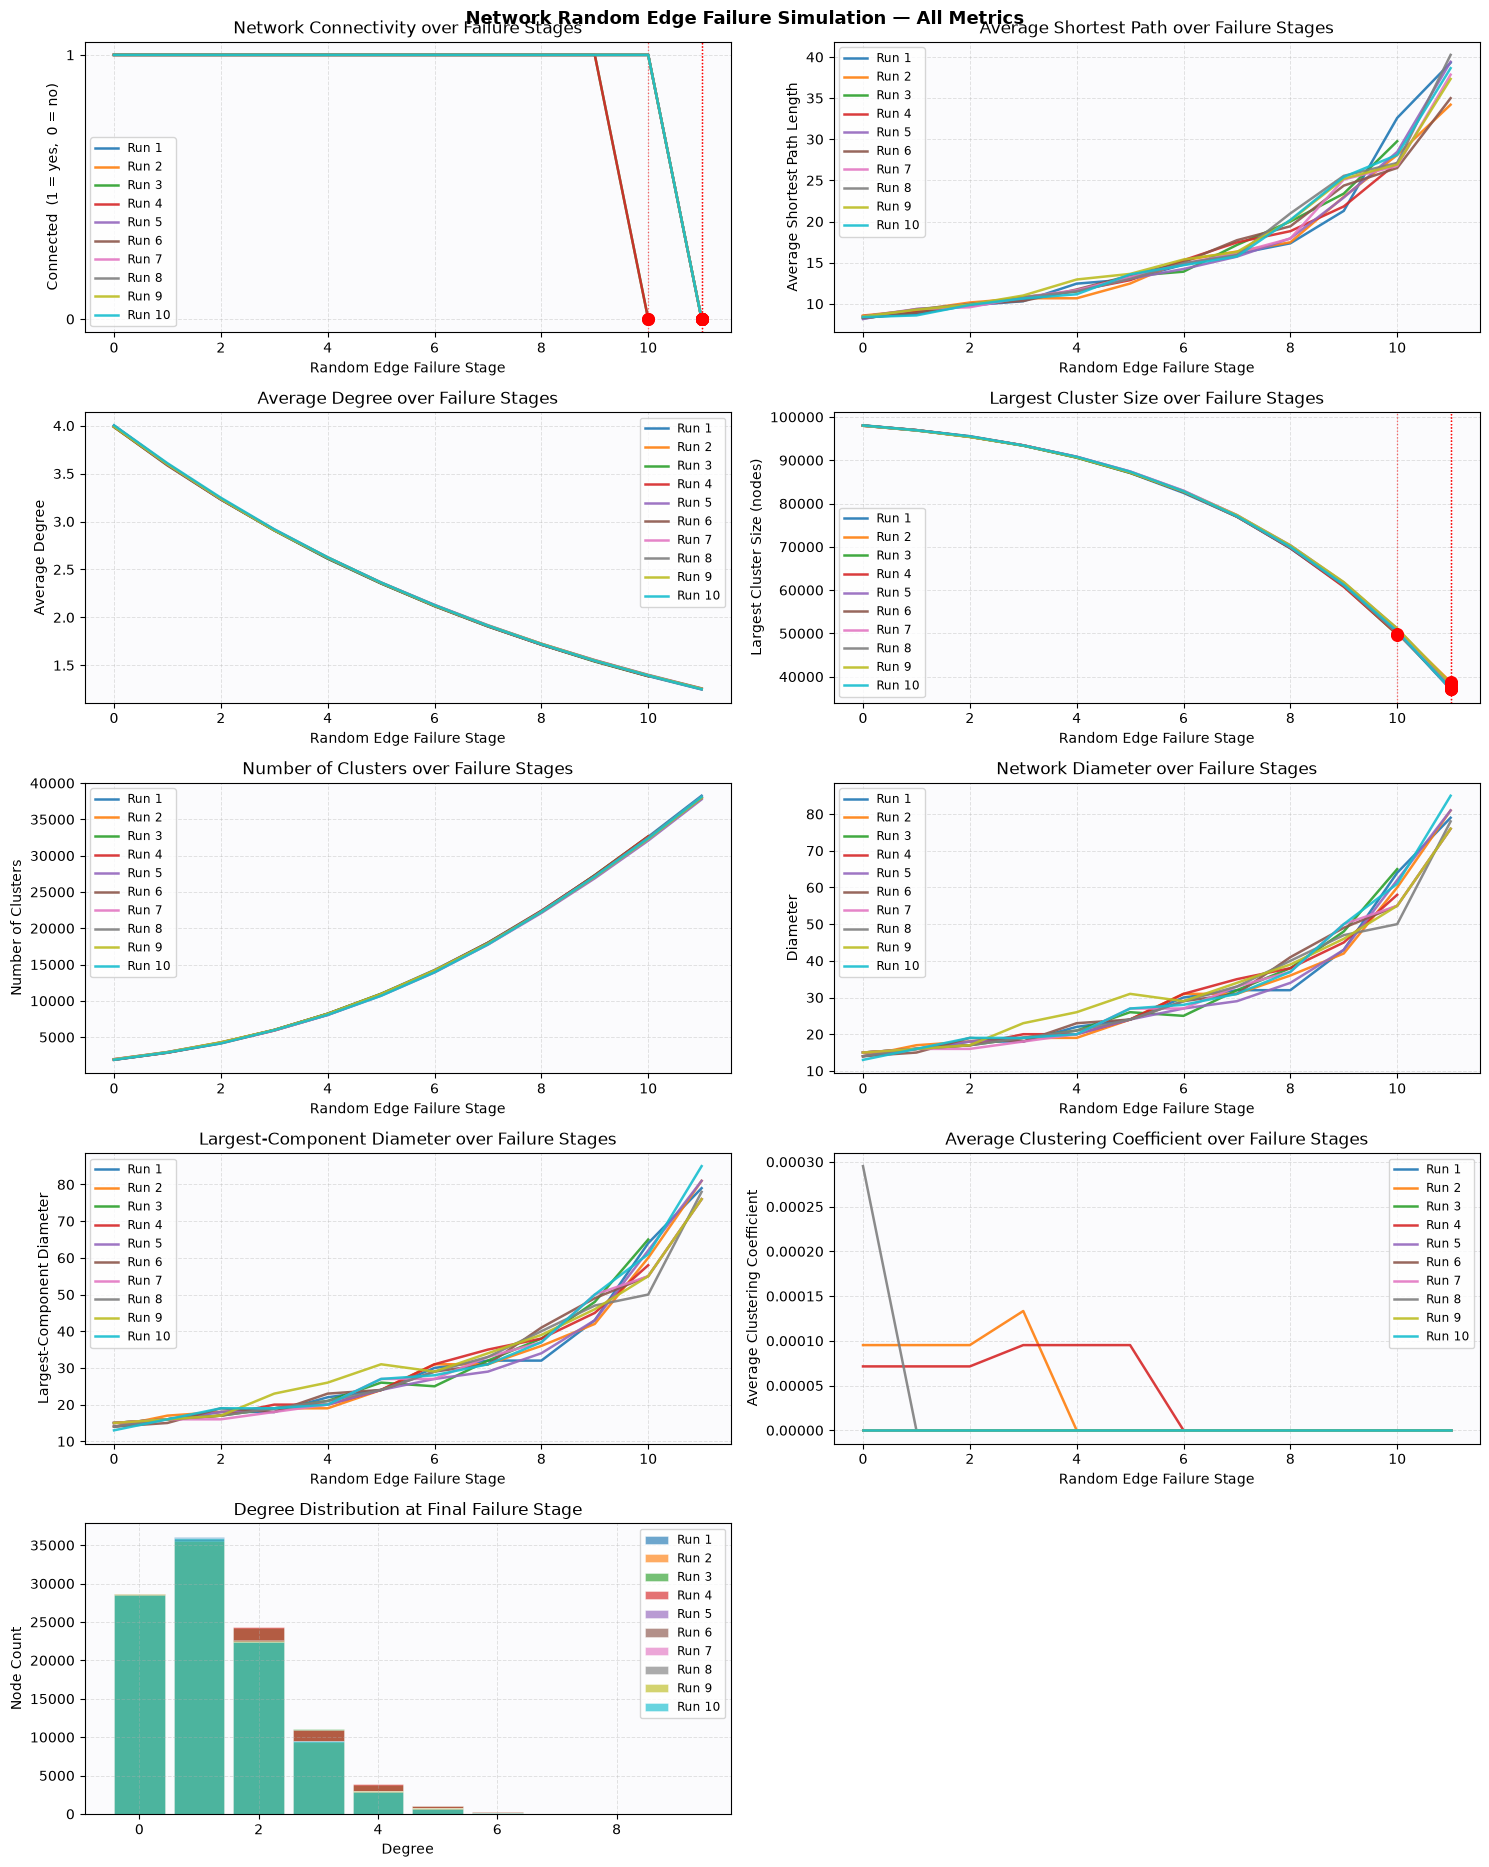

In [6]:
er_vis = SimulationVisualiser(er_runs)
er_vis.plot_all()

### Simulation Results

- **Resilience:** The ER network typically retains a large connected core for many failure stages, although the precise collapse stage varies between generated networks and failure sequences.
- **Paths and diameters:** Shortest-path and diameter estimates change slowly at first, then become more variable as alternative routes are removed near giant-component collapse.
- **Fragmentation:** Component counts remain relatively low early on before rising as the graph separates; the giant component declines most clearly in the later stages.
- **Degree distribution:** Average degree falls progressively, leaving more isolated and low-degree nodes by the final recorded stage.


# Experiment 2: Power-Law Networks


### Simulation Setup and Run

In [7]:
PL_NODE_COUNT = 100000
PL_EXPONENT = 2  # m=2 attachments per new node; produces clear hub structure with avg degree ~4

pl_graph_factory = partial(
    ng.generate_power_law_network,
    node_count=PL_NODE_COUNT,
    exponent=PL_EXPONENT,
)
pl_runs = runner.run_experiment(
    graph_factory=pl_graph_factory,
    num_runs=NUM_RUNS,
    failure_rate=FAILURE_RATE,
    run_parallel=RUNS_IN_PARALLEL,
    max_workers=MAX_WORKERS,
)

runner.export_results(
    pl_runs,
    "simulation_exports/power-law_runs.json",
    "Power-Law",
    {
        "node_count": PL_NODE_COUNT,
        "exponent": PL_EXPONENT,
        "failure_rate": FAILURE_RATE,
        "num_runs": NUM_RUNS,
    },
)

print(f"Power-law: completed {len(pl_runs)} simulation runs.")


Power-law: completed 10 simulation runs.


### Simulation Visualisation

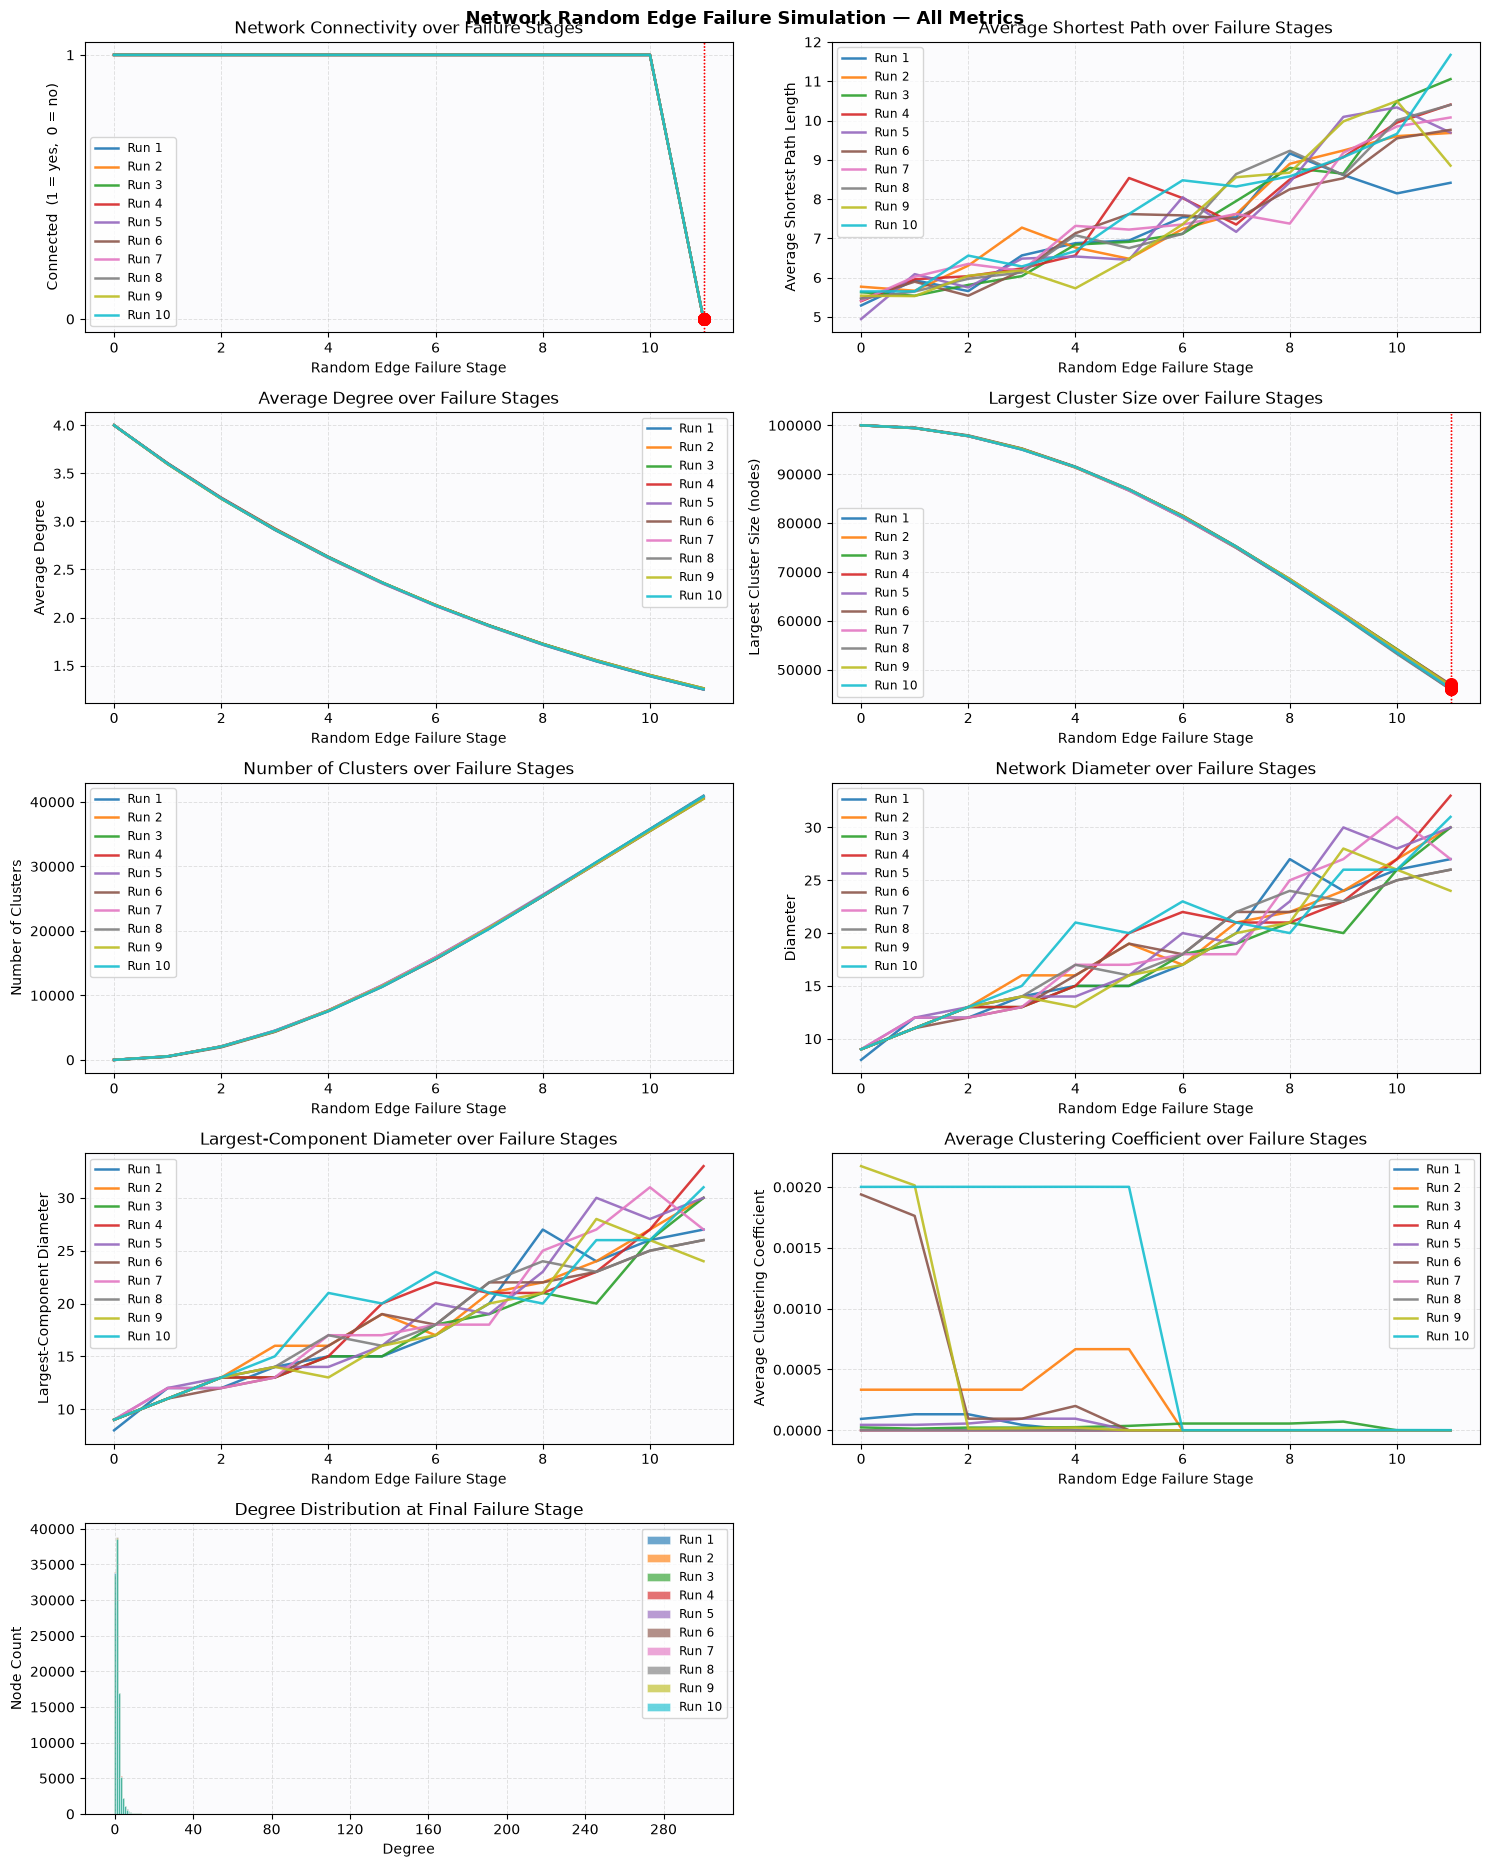

In [8]:
pl_vis = SimulationVisualiser(pl_runs)
pl_vis.plot_all()

### Simulation Results

- **Resilience:** Under continuing random edge failure, the network reaches giant-component collapse after a limited number of stages relative to the more resilient topologies in these runs.
- **Paths and diameters:** Shortest-path and diameter estimates generally increase as the remaining network has fewer routes; their trajectories can differ between runs.
- **Fragmentation:** Average degree and largest-component size decline while the number of components rises.
- **Degree distribution:** At collapse, many nodes may still have local connections, but loss of links around high-degree hubs can prevent those connections forming one large component.


## Experiment 3: Grid Networks
Grid networks are deterministic in their topology — repeated runs with the same parameters produce the same graph structure. The variation across runs therefore reflects the stochastic edge-removal process rather than any change in the underlying lattice.

This makes the grid experiments particularly useful for separating structural effects from the randomness of the degradation process.


### Experiment 3a: 2D Grid Network


### Simulation Setup and Run

In [9]:
GRID_2D_NODE_COUNT = 100000
GRID_2D_DIMENSIONS = 2

# Build once; grid topology is deterministic for fixed parameters.
grid_2d_template_graph = ng.CreateGridNetwork(
    node_count=GRID_2D_NODE_COUNT,
    dimensions=GRID_2D_DIMENSIONS,
).generate()

grid_2d_runs = runner.run_experiment_from_template(
    template_graph=grid_2d_template_graph,
    num_runs=NUM_RUNS,
    failure_rate=FAILURE_RATE,
    run_parallel=RUNS_IN_PARALLEL,
    max_workers=MAX_WORKERS,
)

runner.export_results(
    grid_2d_runs,
    "simulation_exports/2d_grid_runs.json",
    "2D Grid",
    {
        "node_count": GRID_2D_NODE_COUNT,
        "dimensions": GRID_2D_DIMENSIONS,
        "failure_rate": FAILURE_RATE,
        "num_runs": NUM_RUNS,
    },
)

print(f"2D Grid: completed {len(grid_2d_runs)} simulation runs.")


2D Grid: completed 10 simulation runs.


### Simulation Visualisation

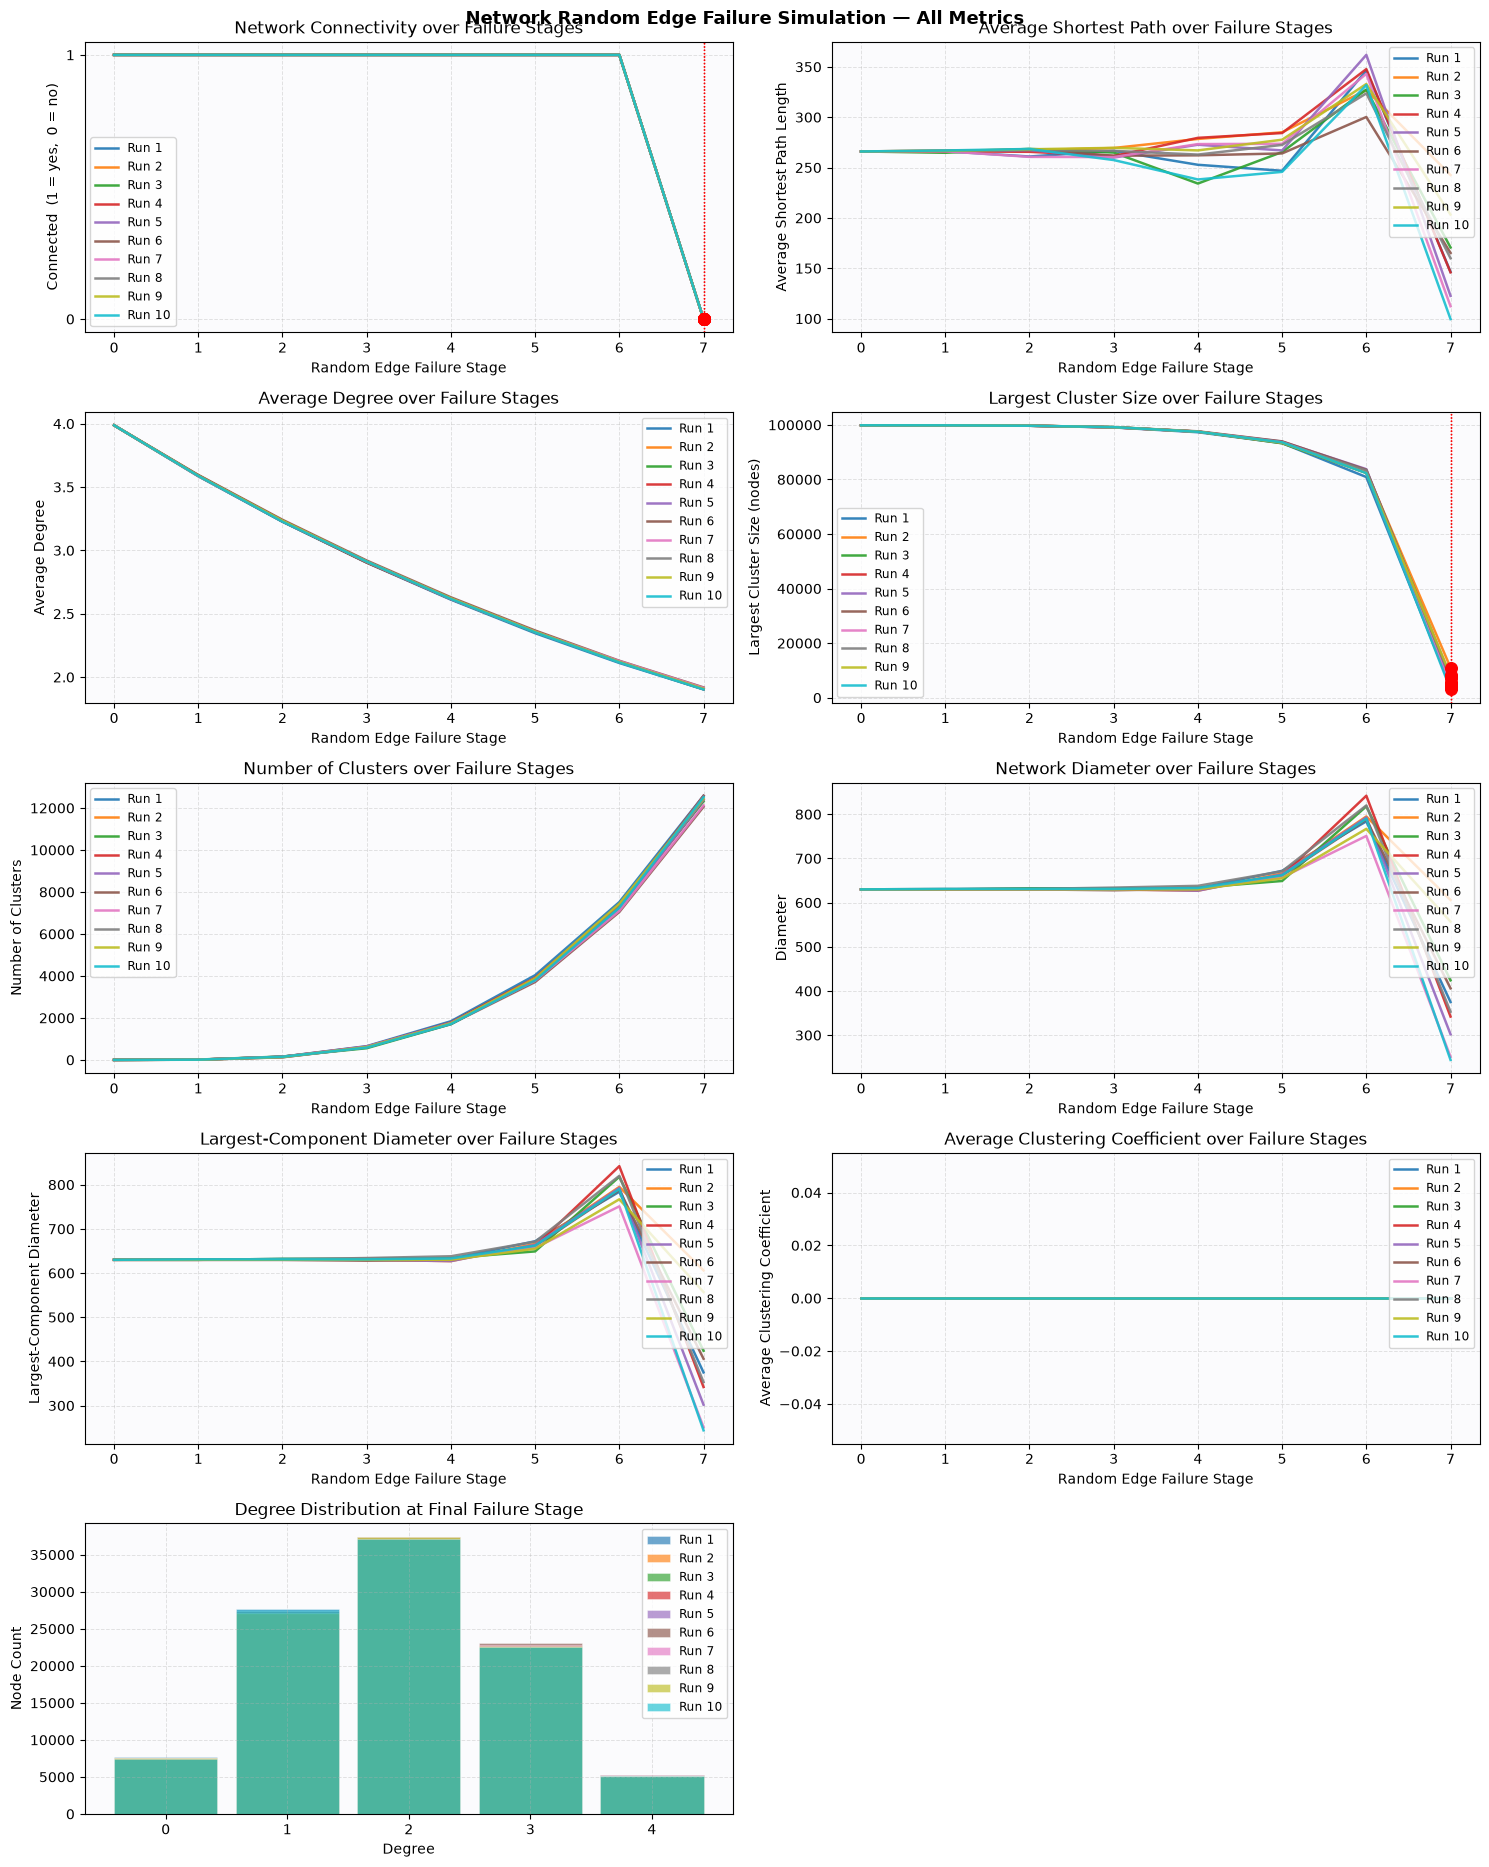

In [10]:
grid_2d_vis = SimulationVisualiser(grid_2d_runs)
grid_2d_vis.plot_all()

### Simulation Results

- **Resilience:** The 2D grid has limited resistance to cumulative random edge failure and reaches giant-component collapse earliest among the grid variants.
- **Metric response:** Average degree declines steadily, while shortest-path and diameter estimates become more constrained or variable as failed edges remove local routes.
- **Fragmentation:** The largest component decreases and the number of disconnected regions rises as edge failures accumulate.
- **Interpretation:** With only four interior neighbours, the 2D lattice has relatively little local redundancy, making it more susceptible to partitioning.


### Experiment 3b: 3D Grid Network


### Simulation Setup and Run

In [11]:
GRID_3D_NODE_COUNT = 100000
GRID_3D_DIMENSIONS = 3

# Build once; grid topology is deterministic for fixed parameters.
grid_3d_template_graph = ng.CreateGridNetwork(
    node_count=GRID_3D_NODE_COUNT,
    dimensions=GRID_3D_DIMENSIONS,
).generate()

grid_3d_runs = runner.run_experiment_from_template(
    template_graph=grid_3d_template_graph,
    num_runs=NUM_RUNS,
    failure_rate=FAILURE_RATE,
    run_parallel=RUNS_IN_PARALLEL,
    max_workers=MAX_WORKERS,
)

runner.export_results(
    grid_3d_runs,
    "simulation_exports/3d_grid_runs.json",
    "3D Grid",
    {
        "node_count": GRID_3D_NODE_COUNT,
        "dimensions": GRID_3D_DIMENSIONS,
        "failure_rate": FAILURE_RATE,
        "num_runs": NUM_RUNS,
    },
)

print(f"3D Grid: completed {len(grid_3d_runs)} simulation runs.")


3D Grid: completed 10 simulation runs.


### Simulation Visualisation

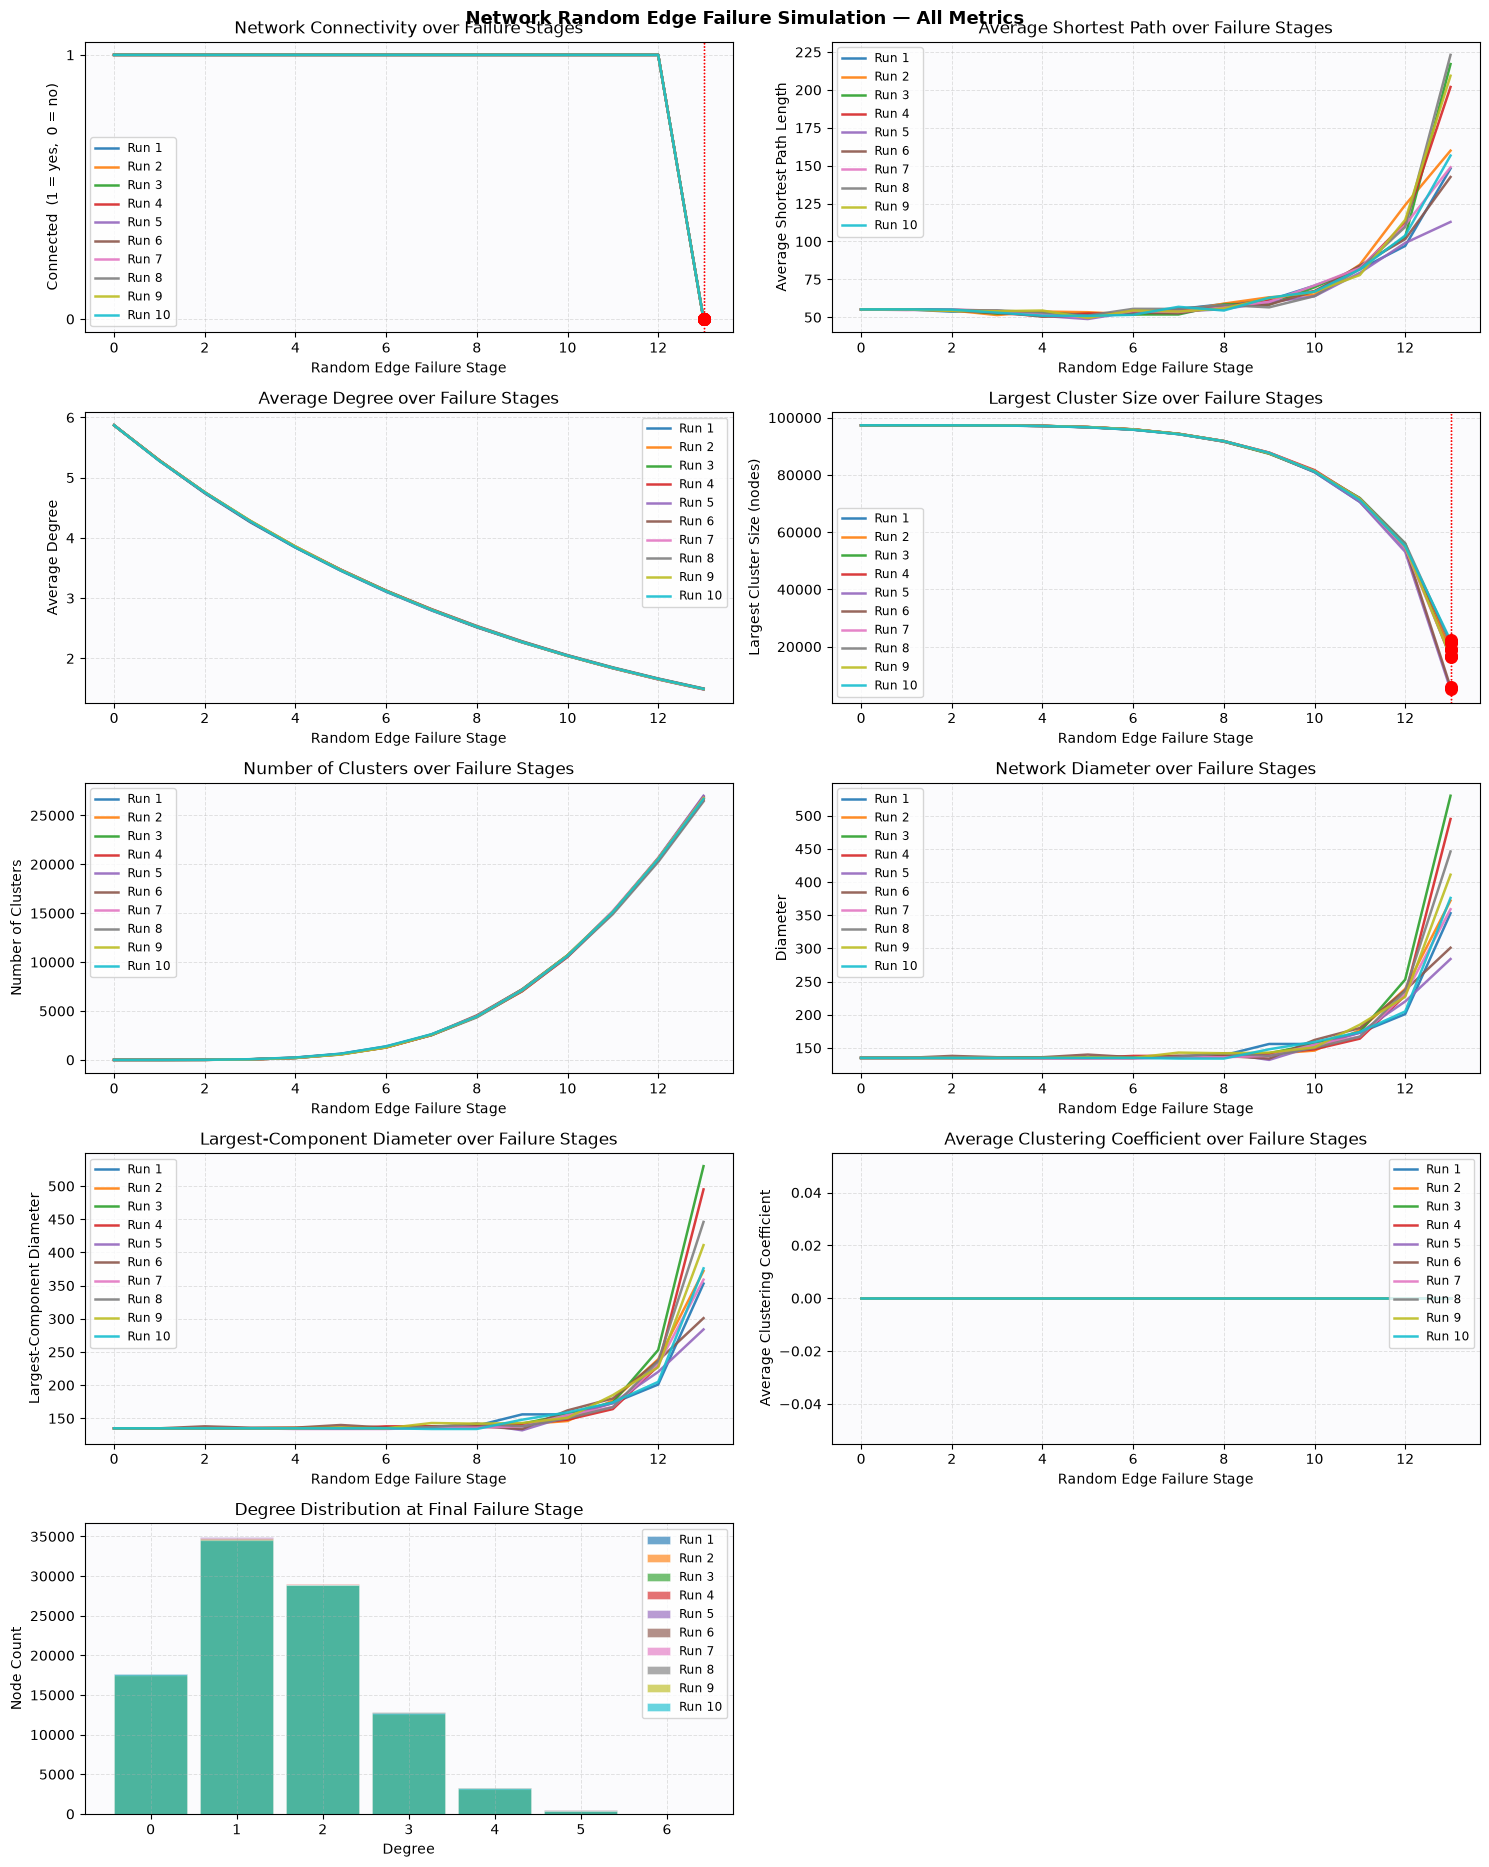

In [12]:
grid_3d_vis = SimulationVisualiser(grid_3d_runs)
grid_3d_vis.plot_all()

### Simulation Results

- **Resilience:** The 3D grid retains a giant component for more stages than the 2D grid, indicating greater resistance to partitioning.
- **Metric response:** Average degree declines steadily; shortest-path and diameter estimates generally rise as edges remove alternative routes.
- **Fragmentation:** The transition to substantial fragmentation occurs later than in 2D, with component counts increasing as the giant component weakens.
- **Interpretation:** Six interior neighbours provide additional local paths, producing a more stable response to random edge failure than the 2D lattice.


### Experiment 3c: 4D Grid Network


### Simulation Setup and Run

In [13]:
GRID_4D_NODE_COUNT = 100000
GRID_4D_DIMENSIONS = 4

# Build once; grid topology is deterministic for fixed parameters.
grid_4d_template_graph = ng.CreateGridNetwork(
    node_count=GRID_4D_NODE_COUNT,
    dimensions=GRID_4D_DIMENSIONS,
).generate()

grid_4d_runs = runner.run_experiment_from_template(
    template_graph=grid_4d_template_graph,
    num_runs=NUM_RUNS,
    failure_rate=FAILURE_RATE,
    run_parallel=RUNS_IN_PARALLEL,
    max_workers=MAX_WORKERS,
)

runner.export_results(
    grid_4d_runs,
    "simulation_exports/4d_grid_runs.json",
    "4D Grid",
    {
        "node_count": GRID_4D_NODE_COUNT,
        "dimensions": GRID_4D_DIMENSIONS,
        "failure_rate": FAILURE_RATE,
        "num_runs": NUM_RUNS,
    },
)

print(f"4D Grid: completed {len(grid_4d_runs)} simulation runs.")


4D Grid: completed 10 simulation runs.


### Simulation Visualisation and Collapse Summary

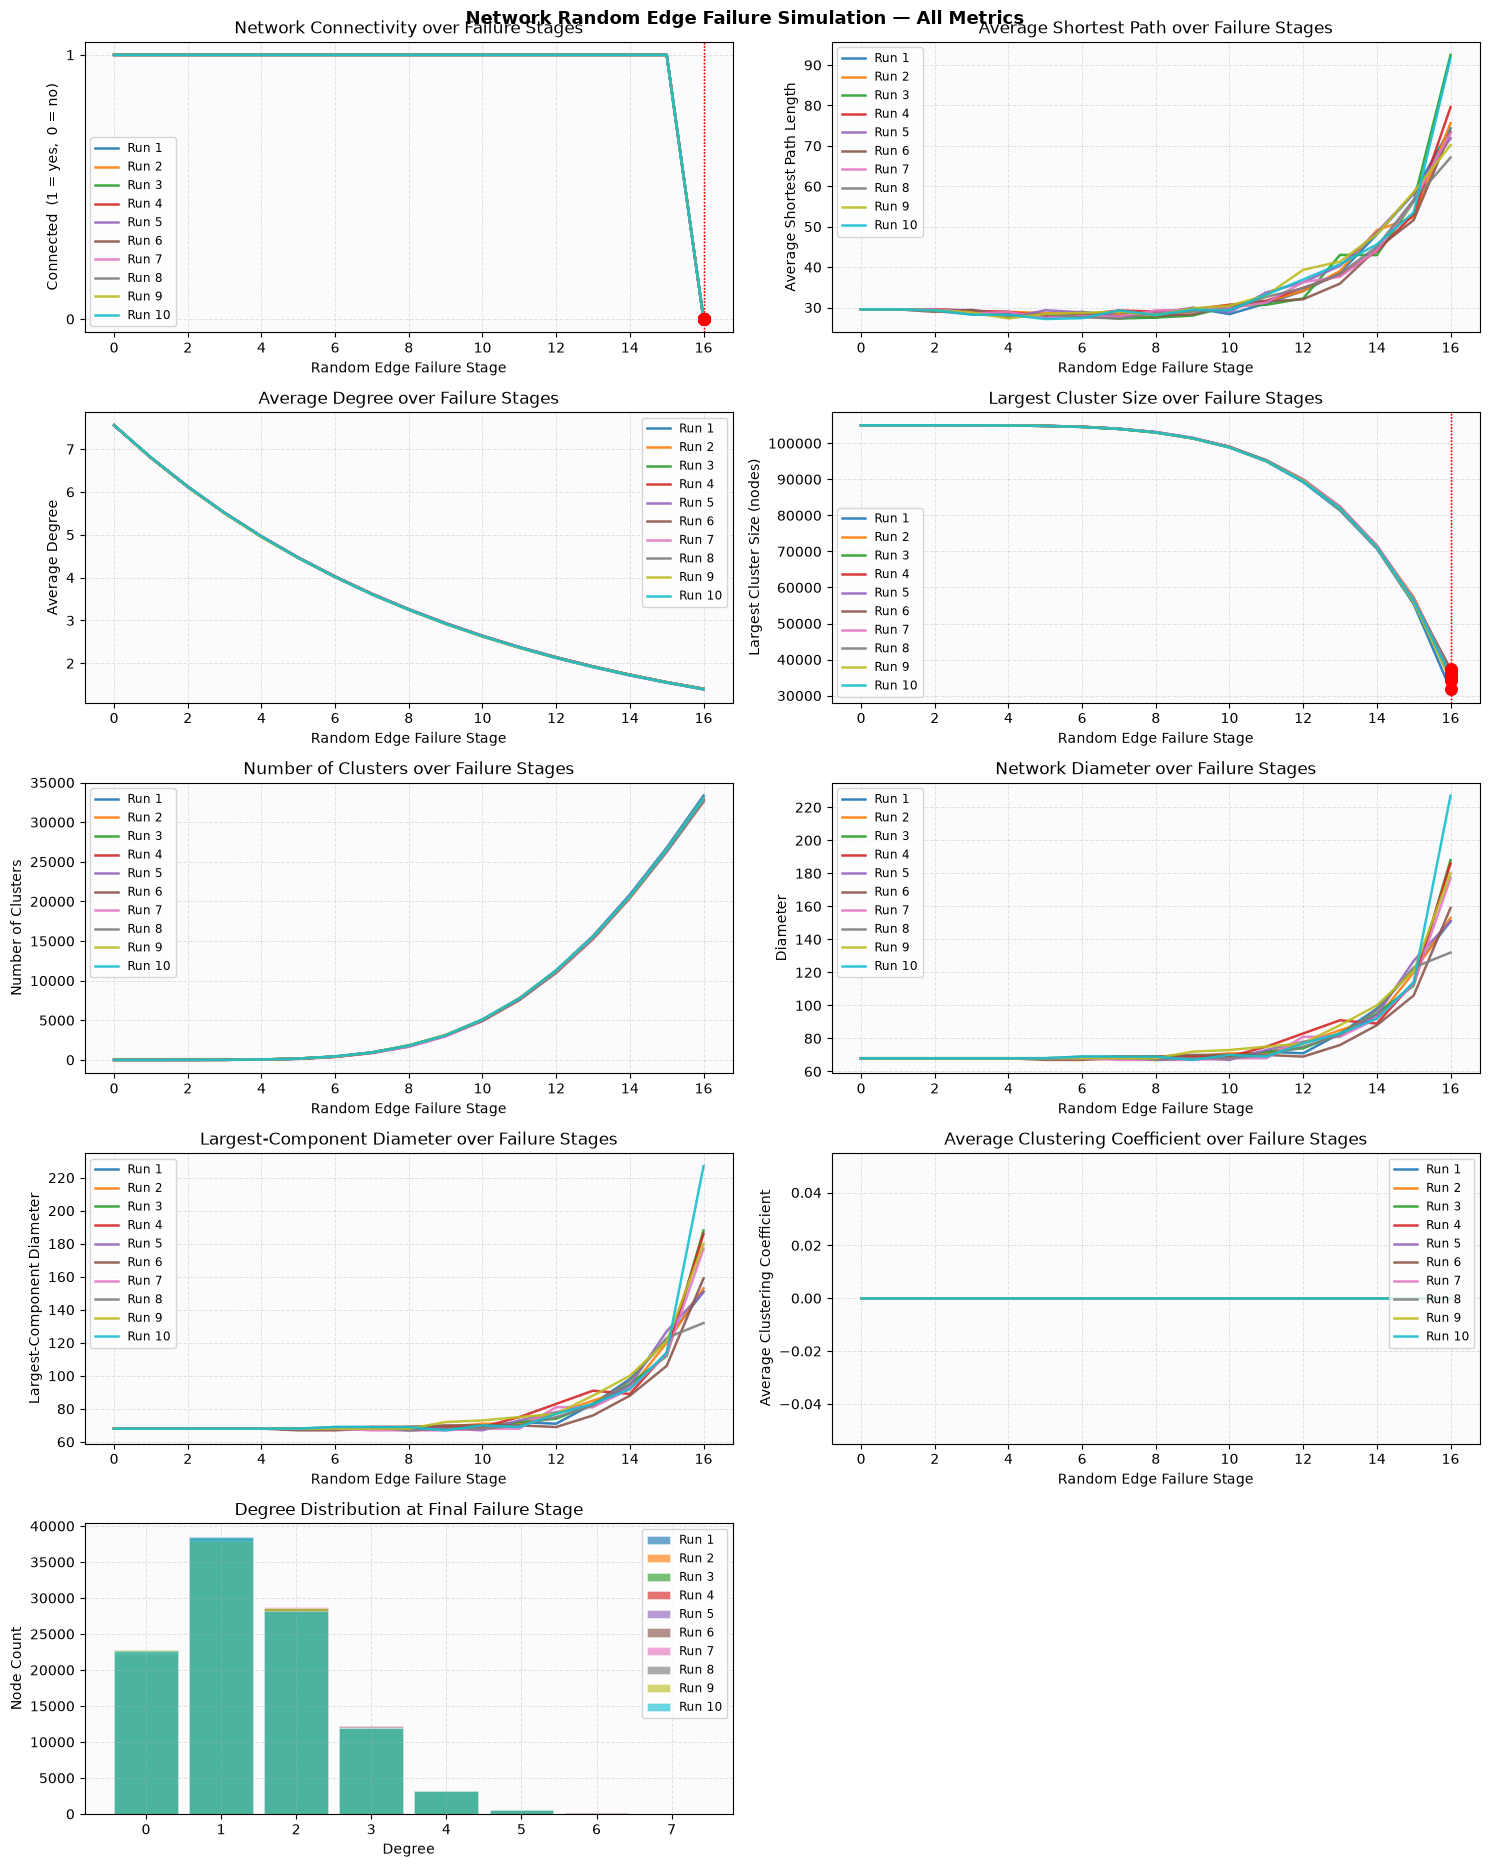

Grid giant-component collapse summary
Topology | Nodes | Collapsed runs | Mean stage +/- SD | Mean edges remaining
      2D |  99856 |          10/10 | 7.00 +/- 0.00 | 47.9%
      3D |  97336 |          10/10 | 13.00 +/- 0.00 | 25.4%
      4D | 104976 |          10/10 | 16.00 +/- 0.00 | 18.5%


In [ ]:
grid_4d_vis = SimulationVisualiser(grid_4d_runs)
grid_4d_vis.plot_all()

### Simulation Results

- **Resilience:** The 4D grid retains a giant component for the most stages of the grid variants, although it still eventually partitions under continued edge failure.
- **Metric response:** Average degree declines throughout; shortest-path and diameter estimates show increasing constraint as local routes are removed.
- **Fragmentation:** The rise in component count and reduction in largest-component size occur later than in the 2D and 3D grids.
- **Interpretation:** Eight interior neighbours provide the greatest local redundancy, giving the most stable response to random edge failure in this grid comparison.

## Overall Results and Analysis


### Overall Findings

- **Erdős–Rényi:** ER provides a resilient contextual baseline. It can retain a large connected core through substantial edge loss, with clear fragmentation emerging nearer giant-component collapse.
- **Power-Law:** Power-Law networks can retain many local connections at collapse, yet fragmentation can accelerate when random edge loss affects routes involving high-degree hubs. Their metric trajectories also show more run-to-run variation.
- **Grid dimensionality:** All grids eventually partition under cumulative random edge failure, but resilience increases from 2D to 3D to 4D. More dimensions provide more local alternative paths and so greater resilience is seen.
- **Metric behaviour:** Across the grid experiments, average degree falls, component counts rise, and the giant component shrinks. Shortest-path and diameter estimates become more constrained or variable as fragmentation develops.
- **Variance:** The 2D grid typically shows the earliest and least stable transition to fragmentation. The 3D and 4D grids have more consistent behaviour because their additional connections provide redundancy.

### Conclusion

- Random edge failure can partition even large, highly regular grids; random placement of failures does not prevent network-wide fragmentation.
- The 2D grid is the most susceptible grid variant, while the 4D grid is the most resilient in this comparison. The rerunnable collapse summary provides the current mean collapse stage and variation between runs.
- This ordering reflects both dimensionality and the higher local degree it creates. The experiment therefore demonstrates that greater local redundancy delays giant-component collapse, rather than isolating dimension as the only cause.
- ER and Power-Law results provide useful context, but the central result is the increasing resilience of structured grids as their dimensionality increases. 

## References

- Cuadra, L., Salcedo-Sanz, S., Del Ser, J., Jimenez-Fernandez, S. and Geem, Z. (2015) 'A Critical Review of Robustness in Power Grids Using Complex Networks Concepts', *Energies*, 8(9), pp. 9211-9265.
- Mureddu, M., Caldarelli, G., Damiano, A., Scala, A. and Meyer-Ortmanns, H. (2016) 'Islanding the power grid on the transmission level: less connections for more security', *Scientific Reports*, 6(1), pp. 34797-.

## Bibliography

- Wang, S., Lv, W., Zhao, L., Nie, S. and Stanley, H.E. (2019) 'Structural and functional robustness of networked critical infrastructure systems under different failure scenarios', *Physica A*, 523, pp. 476-487.
- Qi, X., Zhang, B., Liu, L. and Hu, S. (2017) 'Evaluation and Optimization of Complex Network Resilience against Attacks', in *2017 International Conference on Smart Grid and Electrical Automation (ICSGEA)*. IEEE, pp. 469-472.
